--- Starting Data Verification Script ---
Loading real faces dataset (Domain A)...
Loading painted faces dataset (Domain B)...
Loading metadata...

--- Verification ---
Metadata loaded successfully:
{'img_size': 256, 'batch_size': 4, 'real_faces_samples': 50000, 'painted_faces_samples': 1910, 'domain_a': 'Real Faces (CelebA, 50000 subset)', 'domain_b': 'Painted Faces (Van Gogh)'}

Type of real dataset object: <class 'torch.utils.data.dataset.Subset'>
Length of real dataset: 50000 images
Type of painted dataset object: <class 'torchvision.datasets.folder.ImageFolder'>
Length of painted dataset: 1910 images

Success! Now preparing images for display...
Displaying image windows. Close the windows to end the script.


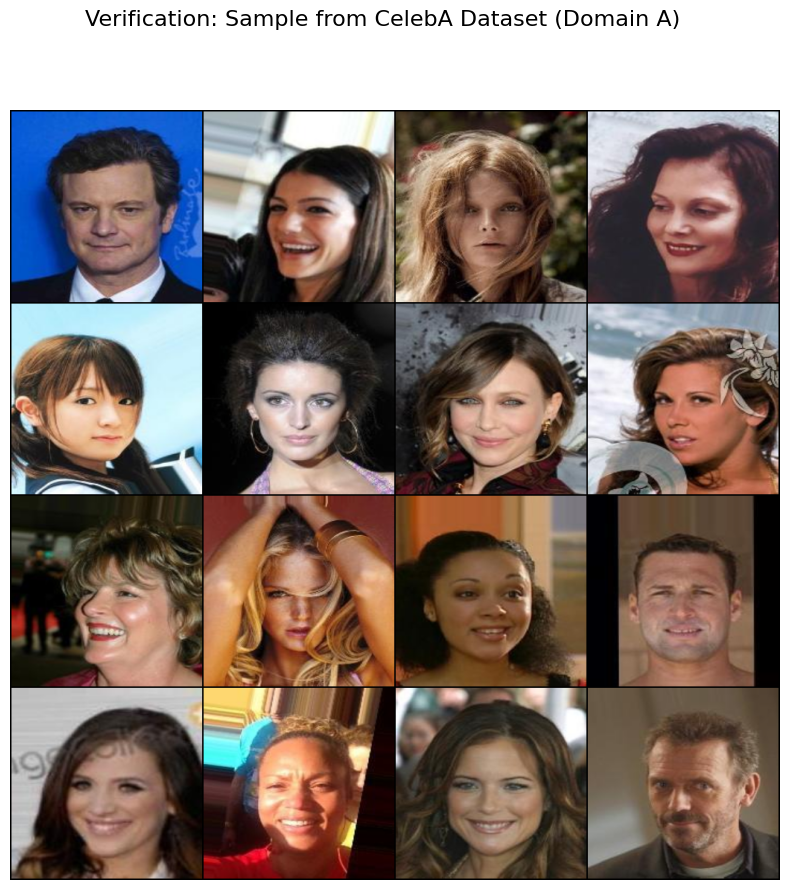

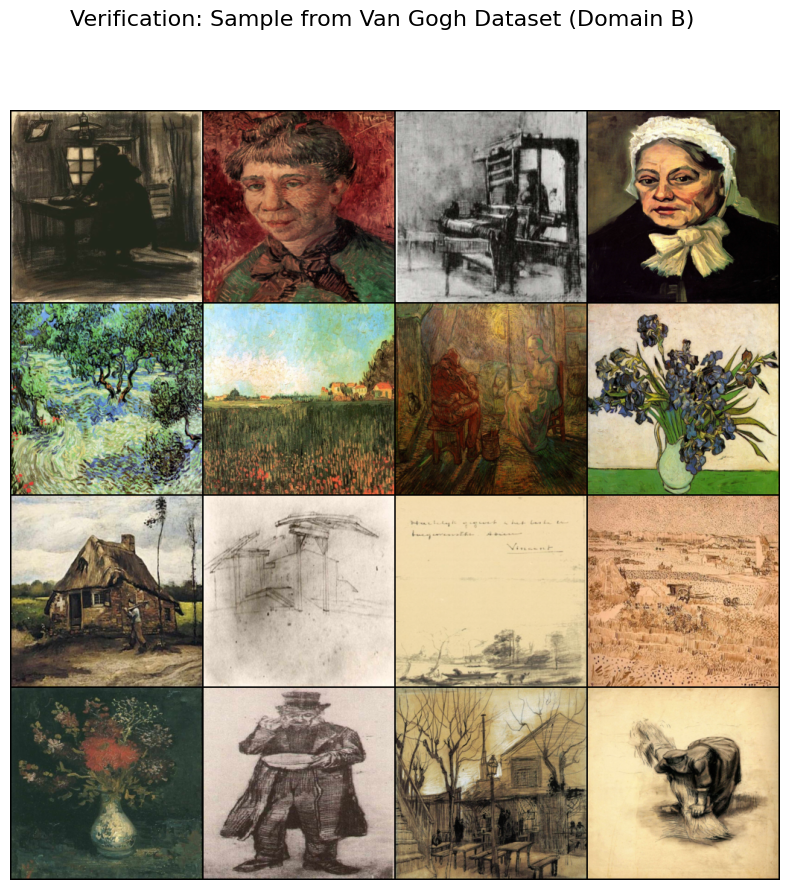


--- Data Verification Complete ---


In [1]:
# test_loaded_data.py

import pickle
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import sys

print("--- Starting Data Verification Script ---")

# --- Step 1: Load the saved files ---
try:
    print("Loading real faces dataset (Domain A)...")
    with open('./saved_cyclegan_datasets/real_faces_dataset.pkl', 'rb') as f:
        dataset_real = pickle.load(f)
    
    print("Loading painted faces dataset (Domain B)...")
    with open('./saved_cyclegan_datasets/painted_faces_dataset.pkl', 'rb') as f:
        dataset_painted = pickle.load(f)
        
    print("Loading metadata...")
    with open('./saved_cyclegan_datasets/metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)
except FileNotFoundError as e:
    print(f"\nERROR: Could not find the file {e.filename}.")
    print("Please make sure you have run 'cyclegan_data_preprocessing.py' successfully first.")
    sys.exit()

print("\n--- Verification ---")
print("Metadata loaded successfully:")
print(metadata)
print(f"\nType of real dataset object: {type(dataset_real)}")
print(f"Length of real dataset: {len(dataset_real)} images")
print(f"Type of painted dataset object: {type(dataset_painted)}")
print(f"Length of painted dataset: {len(dataset_painted)} images")

if len(dataset_real) == 0 or len(dataset_painted) == 0:
    print("\nERROR: One of the datasets is empty! Check your file paths and structure.")
    sys.exit()

# --- Step 2: Create temporary DataLoaders to get a batch ---
dataloader_real = torch.utils.data.DataLoader(dataset_real, batch_size=16, shuffle=True)
dataloader_painted = torch.utils.data.DataLoader(dataset_painted, batch_size=16, shuffle=True)

# --- Step 3: Get one batch from each and visualize ---
print("\nSuccess! Now preparing images for display...")

# Visualize Real Faces (CelebA)
real_batch, _ = next(iter(dataloader_real))
plt.figure(figsize=(10, 10))
plt.suptitle("Verification: Sample from CelebA Dataset (Domain A)", fontsize=16)
# De-normalize images from [-1, 1] to [0, 1] for display
grid_real = make_grid(real_batch * 0.5 + 0.5, nrow=4)
plt.imshow(np.transpose(grid_real.numpy(), (1, 2, 0)))
plt.axis('off')

# Visualize Painted Faces (Van Gogh)
painted_batch, _ = next(iter(dataloader_painted))
plt.figure(figsize=(10, 10))
plt.suptitle("Verification: Sample from Van Gogh Dataset (Domain B)", fontsize=16)
# De-normalize images
grid_painted = make_grid(painted_batch * 0.5 + 0.5, nrow=4)
plt.imshow(np.transpose(grid_painted.numpy(), (1, 2, 0)))
plt.axis('off')

print("Displaying image windows. Close the windows to end the script.")
plt.show()

print("\n--- Data Verification Complete ---")